In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [86]:
df=pd.read_csv('C:\\Users\\bapai\\WORK\\Projects\\SKE309_Project\\Student_Performance.csv')
df.head(5)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [87]:
df1 = df.drop(['student_id', 'math_score', 'science_score', 'english_score'], axis=1)
df1.head(5)

,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,overall_score,final_grade
0,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,53.1,e
1,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,61.3,d
2,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,89.6,b
3,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,41.6,e
4,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,25.4,f


In [88]:
df2 = df1.copy()

# Gender: male=1, female=0, other=NaN or drop
df2['gender'] = df2['gender'].map({'male': 1, 'female': 0})

# School type: public=0, private=1
df2['school_type'] = df2['school_type'].map({'public': 0, 'private': 1})

# Parent education: encode as -1, 0, 1
education_mapping = {'no formal': -1, 'high school': 0, 'diploma': 0, 'graduate': 1, 'post graduate': 1, 'phd': 1}
df2['parent_education'] = df2['parent_education'].map(education_mapping)

# Internet access: yes=1, no=0
df2['internet_access'] = df2['internet_access'].map({'yes': 1, 'no': 0})

# Travel time: encode numerically
travel_mapping = {'<15 min': 0, '15-30 min': 1, '30-60 min': 2, '>60 min': 3}
df2['travel_time'] = df2['travel_time'].map(travel_mapping)

# Extra activities: yes=1, no=0
df2['extra_activities'] = df2['extra_activities'].map({'yes': 1, 'no': 0})

# Study method: encode as categories
study_mapping = {'notes': 0, 'textbook': 1, 'coaching': 2, 'group study': 3, 'online videos': 4, 'mixed': 5}
df2['study_method'] = df2['study_method'].map(study_mapping)

# Final grade: encode as -2, -1, 0, 1, 2
grade_mapping = {'f': -2, 'e': -1, 'd': 0, 'c': 1, 'b': 2, 'a': 3}
df2['final_grade'] = df2['final_grade'].map(grade_mapping)

df2.head(10)

,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,overall_score,final_grade
0,14,1.0,0,1,3.1,84.3,1,0,1,0,53.1,-1
1,18,0.0,0,1,3.7,87.8,1,3,0,1,61.3,0
2,17,0.0,1,1,7.9,65.5,0,0,0,0,89.6,2
3,16,NaN,0,0,1.1,58.1,0,1,0,0,41.6,-1
4,16,0.0,0,0,1.3,61.0,1,2,1,3,25.4,-2
5,19,1.0,0,-1,3.8,69.6,1,3,1,2,63.5,0
6,14,0.0,1,1,1.8,81.6,1,2,0,1,39.1,-2
7,18,0.0,1,1,5.6,59.4,1,3,1,3,69.6,0
8,15,NaN,1,0,3.2,89.6,1,1,1,5,55.2,0
9,14,0.0,0,0,6.8,62.4,1,3,0,5,69.6,0


In [89]:
corr = df2.corr()

corr_overall = corr['overall_score'].drop('overall_score').abs().sort_values(ascending=False)
corr_grade = corr['final_grade'].abs().sort_values(ascending=False)

print("Top correlations with overall_score:")
print(corr_overall.head(10))

print("\nTop correlations with final_grade:")
print(corr_grade.head(10))

print("\nMost impactful feature for overall_score:", corr_overall.index[0], corr_overall.iloc[0])
print("Most impactful feature for final_grade:", corr_grade.index[0], corr_grade.iloc[0])

Top correlations with overall_score:
final_grade              0.972379
study_hours              0.905771
attendance_percentage    0.292762
extra_activities         0.007596
internet_access          0.005152
gender                   0.005150
travel_time              0.004534
age                      0.003847
study_method             0.003226
parent_education         0.001798
Name: overall_score, dtype: float64

Top correlations with final_grade:
final_grade              1.000000
overall_score            0.972379
study_hours              0.879197
attendance_percentage    0.286868
extra_activities         0.008908
gender                   0.008543
age                      0.008319
internet_access          0.004943
travel_time              0.003800
school_type              0.003724
Name: final_grade, dtype: float64

Most impactful feature for overall_score: final_grade 0.9723788628399995
Most impactful feature for final_grade: final_grade 1.0


Dataset shape: (25000, 16)

Encoded dataframe summary:
                         count       mean        std   min   25%   50%   75%  \
age                    25000.0  16.482760   1.703895  14.0  15.0  16.0  18.0   
gender                 16537.0   0.498700   0.500013   0.0   0.0   0.0   1.0   
school_type            25000.0   0.509000   0.499929   0.0   0.0   1.0   1.0   
parent_education       25000.0   0.332920   0.740558  -1.0   0.0   0.0   1.0   
study_hours            25000.0   4.253224   2.167541   0.5   2.4   4.3   6.1   
attendance_percentage  25000.0  75.084084  14.373171  50.0  62.8  75.1  87.5   
internet_access        25000.0   0.849080   0.357978   0.0   1.0   1.0   1.0   
travel_time            25000.0   1.502000   1.110624   0.0   1.0   2.0   2.0   
extra_activities       25000.0   0.500000   0.500010   0.0   0.0   0.5   1.0   
study_method           25000.0   2.512880   1.720939   0.0   1.0   3.0   4.0   
overall_score          25000.0  64.006172  18.932025  14.5  49.0 

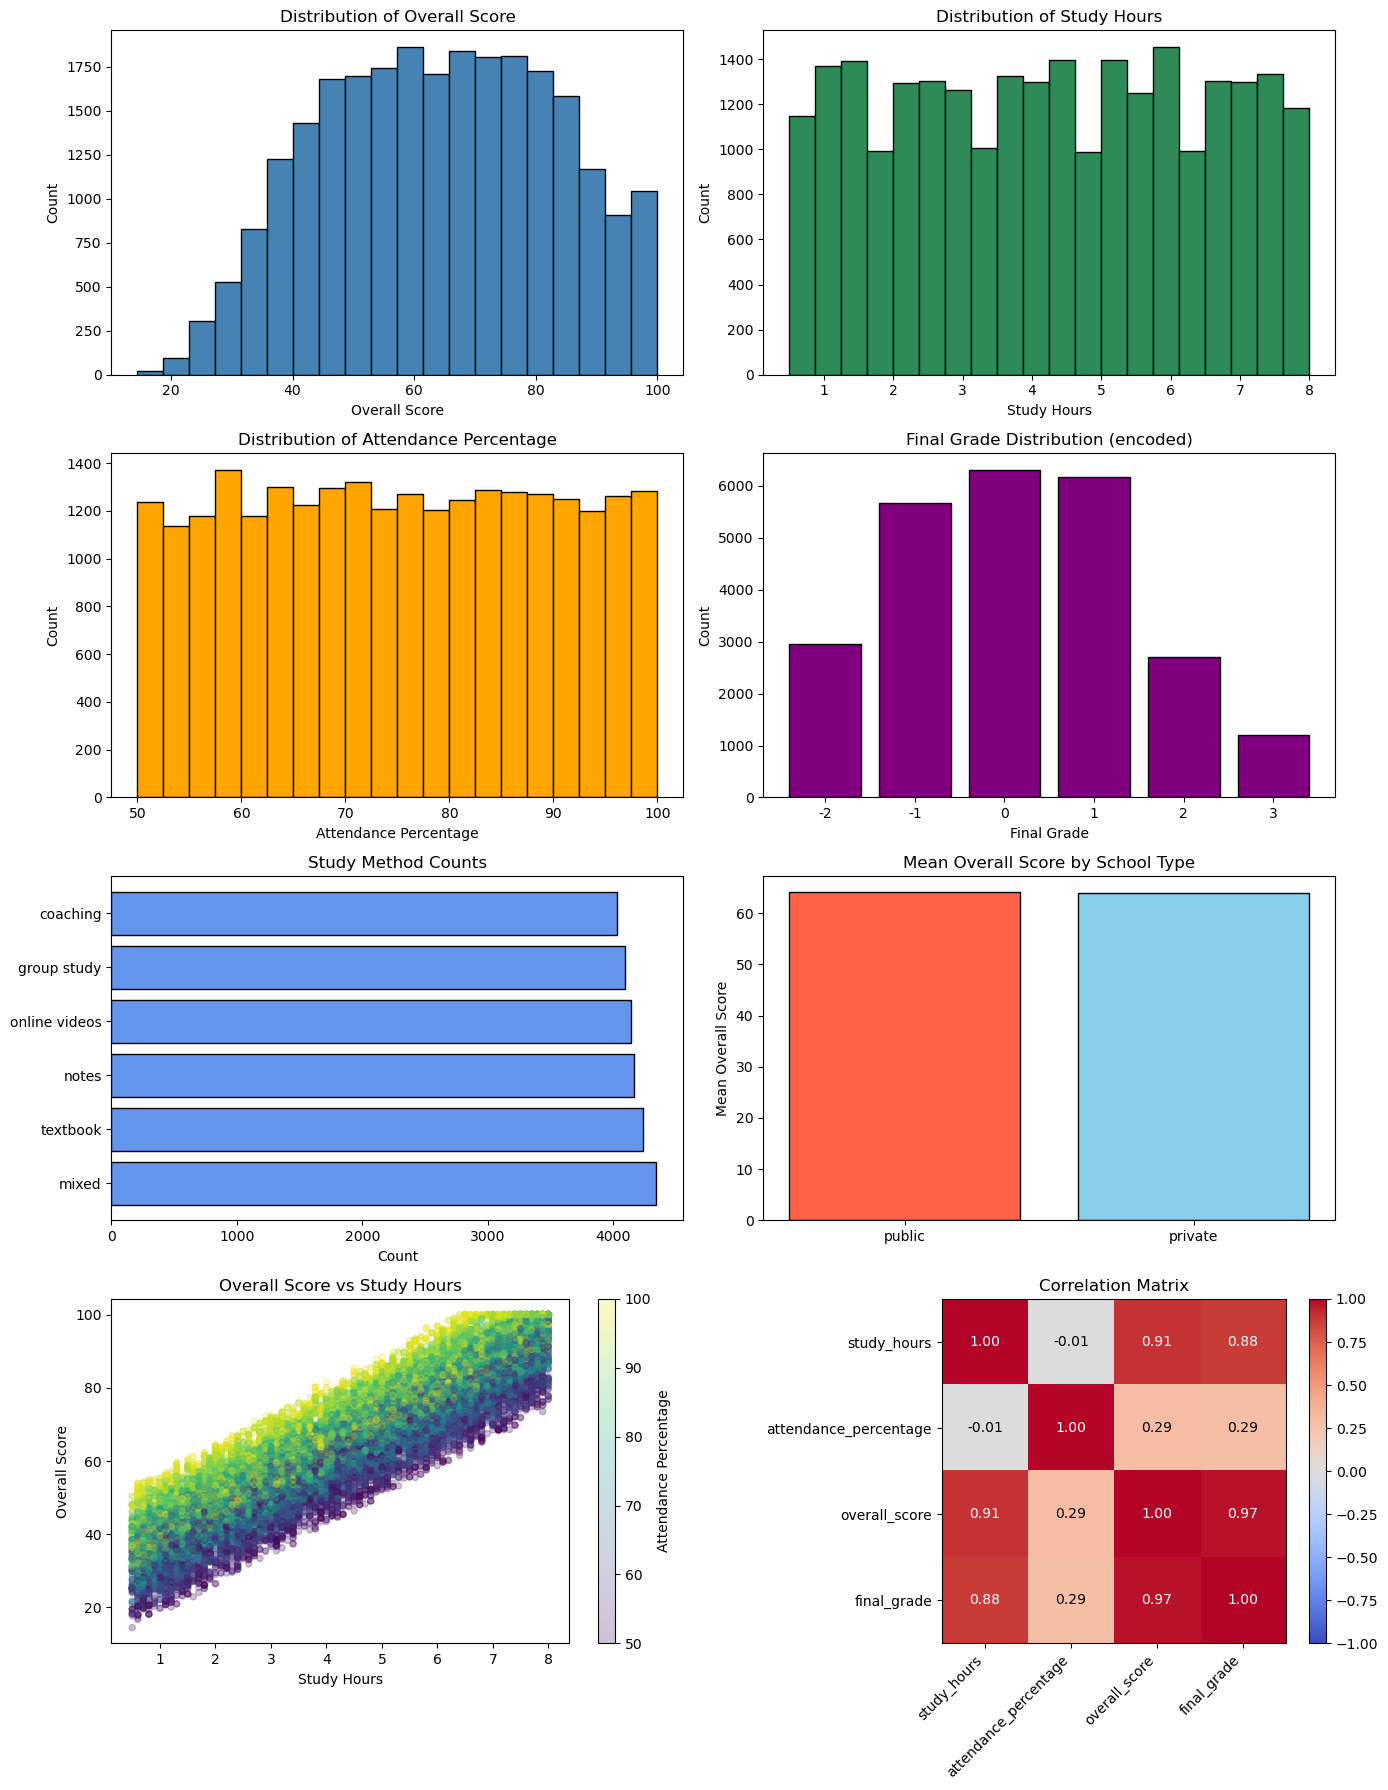

In [90]:
print("Dataset shape:", df.shape)
print("\nEncoded dataframe summary:")
print(df2.describe().transpose())

print("\nMissing values in df2:")
print(df2.isna().sum())

print("\nCategorical counts:")
for col in ['gender', 'school_type', 'parent_education', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'final_grade']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False).sort_index())

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

axes[0].hist(df2['overall_score'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Overall Score')
axes[0].set_xlabel('Overall Score')
axes[0].set_ylabel('Count')

axes[1].hist(df2['study_hours'].dropna(), bins=20, color='seagreen', edgecolor='black')
axes[1].set_title('Distribution of Study Hours')
axes[1].set_xlabel('Study Hours')
axes[1].set_ylabel('Count')

axes[2].hist(df2['attendance_percentage'].dropna(), bins=20, color='orange', edgecolor='black')
axes[2].set_title('Distribution of Attendance Percentage')
axes[2].set_xlabel('Attendance Percentage')
axes[2].set_ylabel('Count')

grade_counts = df2['final_grade'].value_counts().sort_index()
axes[3].bar(grade_counts.index.astype(str), grade_counts.values, color='purple', edgecolor='black')
axes[3].set_title('Final Grade Distribution (encoded)')
axes[3].set_xlabel('Final Grade')
axes[3].set_ylabel('Count')

study_method_counts = df['study_method'].value_counts().sort_values(ascending=False)
axes[4].barh(study_method_counts.index, study_method_counts.values, color='cornflowerblue', edgecolor='black')
axes[4].set_title('Study Method Counts')
axes[4].set_xlabel('Count')

school_means = df2.groupby('school_type')['overall_score'].mean()
axes[5].bar(['public', 'private'], school_means.values, color=['tomato', 'skyblue'], edgecolor='black')
axes[5].set_title('Mean Overall Score by School Type')
axes[5].set_ylabel('Mean Overall Score')

scatter = axes[6].scatter(df2['study_hours'], df2['overall_score'], alpha=0.25, s=20, c=df2['attendance_percentage'], cmap='viridis')
axes[6].set_title('Overall Score vs Study Hours')
axes[6].set_xlabel('Study Hours')
axes[6].set_ylabel('Overall Score')
cbar = fig.colorbar(scatter, ax=axes[6])
cbar.set_label('Attendance Percentage')

corr_matrix = df2[['study_hours', 'attendance_percentage', 'overall_score', 'final_grade']].corr()
im = axes[7].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[7].set_title('Correlation Matrix')
axes[7].set_xticks(range(len(corr_matrix)))
axes[7].set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
axes[7].set_yticks(range(len(corr_matrix)))
axes[7].set_yticklabels(corr_matrix.index)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        axes[7].text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center',
                     color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
fig.colorbar(im, ax=axes[7], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [91]:
from sklearn.preprocessing import MinMaxScaler

df2_norm = df2.fillna(df2.mean())
scaler = MinMaxScaler()
df2_scaled = pd.DataFrame(scaler.fit_transform(df2_norm), columns=df2_norm.columns, index=df2_norm.index)

df2_scaled.head()

,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,overall_score,final_grade
0,0.0,1.0000,0.0,1.0,0.346667,0.686,1.0,0.000000,1.0,0.0,0.451462,0.2
1,0.8,0.0000,0.0,1.0,0.426667,0.756,1.0,1.000000,0.0,0.2,0.547368,0.4
2,0.6,0.0000,1.0,1.0,0.986667,0.310,0.0,0.000000,0.0,0.0,0.878363,0.8
3,0.4,0.4987,0.0,0.5,0.080000,0.162,0.0,0.333333,0.0,0.0,0.316959,0.2
4,0.4,0.0000,0.0,0.5,0.106667,0.220,1.0,0.666667,1.0,0.6,0.127485,0.0


In [92]:
X = df2.drop(columns=['overall_score'])
y = df2['overall_score']

X = X.fillna(X.mean())

lr_model = LinearRegression()
lr_model.fit(X, y)

print("Intercept:", lr_model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"  {feature}: {coef}")

Intercept: 37.931379989451514
Coefficients:
  age: 0.022213987269559567
  gender: 0.04182746321747597
  school_type: 0.012176719228900266
  parent_education: 0.0011265675136277326
  study_hours: 3.0860489860011278
  attendance_percentage: 0.150237761377567
  internet_access: 0.05923094520761029
  travel_time: 0.004995058656822888
  extra_activities: -0.0896809357438262
  study_method: -0.005734064308649012
  final_grade: 8.899502358811024


MSE: 12.5154
RMSE: 3.5377
R2 score: 0.9651
   actual  predicted  residual
0    53.1  51.587173  1.512827
1    61.3  63.010097 -1.710097
2    89.6  90.341686 -0.741686
3    41.6  41.536624  0.063376
4    25.4  33.626504 -8.226504


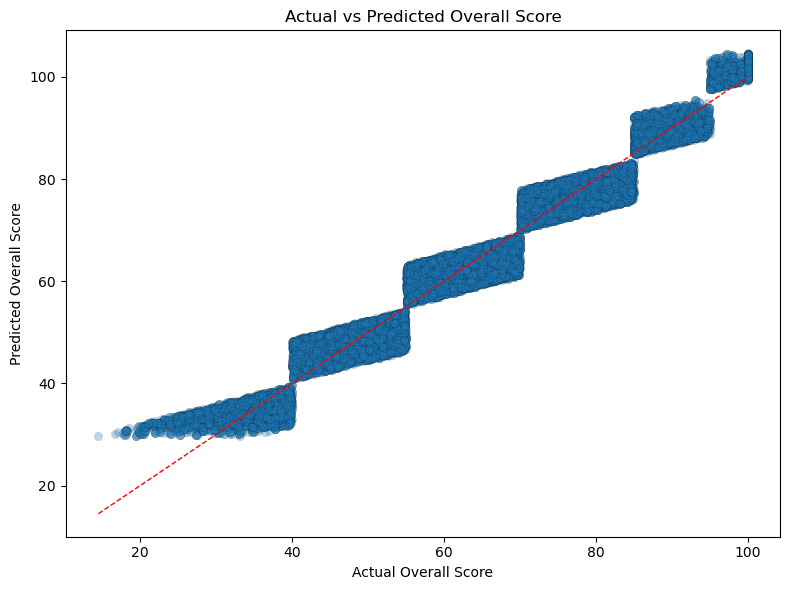

In [93]:
y_pred = lr_model.predict(X)

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 score: {r2:.4f}")

results = pd.DataFrame({
    "actual": y,
    "predicted": y_pred,
    "residual": y - y_pred
})

print(results.head())

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.3, edgecolor='k', linewidth=0.2)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1)
plt.xlabel("Actual Overall Score")
plt.ylabel("Predicted Overall Score")
plt.title("Actual vs Predicted Overall Score")
plt.tight_layout()
plt.show()